## Import Lib + Load Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pointbiserialr, chi2_contingency
from sklearn.ensemble import RandomForestClassifier

In [2]:
df = pd.read_csv("marketing_campaign.csv", sep="\t")
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0


## Data Cleaning

In [3]:
print(f"duplicate ID values: {df['ID'].duplicated().sum()}")
df = df.drop(columns=["ID"])
print(f"shape after dropping ID: {df.shape}")

duplicate ID values: 0
shape after dropping ID: (2240, 28)


In [4]:
print(f"Z_CostContact unique values: {df['Z_CostContact'].unique()}")
print(f"Z_Revenue unique values: {df['Z_Revenue'].unique()}")
# Both columns take exactly one value across all rows — zero variance, no predictive content.
df = df.drop(columns=["Z_CostContact", "Z_Revenue"])
print(f"shape after dropping constant columns: {df.shape}")

Z_CostContact unique values: [3]
Z_Revenue unique values: [11]
shape after dropping constant columns: (2240, 26)


In [5]:
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"], format="%d-%m-%Y")
print(f"Dt_Customer range: {df['Dt_Customer'].min().date()} to {df['Dt_Customer'].max().date()}")

# Customer_Tenure_Days: days enrolled as of the dataset's last enrollment date — a simple, easy-to-justify
# derived feature in place of the raw date string, same "derived, not raw" pattern used for Installs/Size/Price
# in google_play_data.
reference_date = df["Dt_Customer"].max()
df["Customer_Tenure_Days"] = (reference_date - df["Dt_Customer"]).dt.days
df["Customer_Tenure_Days"].describe()

Dt_Customer range: 2012-07-30 to 2014-06-29


count    2240.000000
mean      353.582143
std       202.122512
min         0.000000
25%       180.750000
50%       355.500000
75%       529.000000
max       699.000000
Name: Customer_Tenure_Days, dtype: float64

In [6]:
reference_year = df["Dt_Customer"].dt.year.max()
df["Age"] = reference_year - df["Year_Birth"]
print(df["Age"].describe())

# Three rows carry an implausible Year_Birth (1893, 1899, 1900 -> age 121, 115, 114) — genuine data-entry
# errors, not a real elderly-customer segment. Small n, dropped outright rather than capped/imputed.
age_outliers = df[df["Age"] > 100]
print(f"\nage outlier rows ({len(age_outliers)}):")
print(age_outliers[["Year_Birth", "Age"]])

df = df[df["Age"] <= 100].reset_index(drop=True)
print(f"\nshape after dropping age outliers: {df.shape}")

count    2240.000000
mean       45.194196
std        11.984069
min        18.000000
25%        37.000000
50%        44.000000
75%        55.000000
max       121.000000
Name: Age, dtype: float64

age outlier rows (3):
     Year_Birth  Age
192        1900  114
239        1893  121
339        1899  115

shape after dropping age outliers: (2237, 28)


In [7]:
print("Marital_Status before:")
print(df["Marital_Status"].value_counts())

# "Absurd" (2 rows) and "YOLO" (2 rows) are joke entries, not real categories. "Alone" (3 rows) is a
# genuine status but semantically identical to "Single" and too small to model as its own category —
# folded in alongside the joke labels rather than kept as a 3-row category or a vague "Other" bucket.
df["Marital_Status"] = df["Marital_Status"].replace({"Absurd": "Single", "YOLO": "Single", "Alone": "Single"})

print("\nMarital_Status after:")
print(df["Marital_Status"].value_counts())

Marital_Status before:
Marital_Status
Married     864
Together    579
Single      479
Divorced    231
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: count, dtype: int64

Marital_Status after:
Marital_Status
Married     864
Together    579
Single      486
Divorced    231
Widow        77
Name: count, dtype: int64


In [8]:
df["Education"].value_counts()

Education
Graduation    1127
PhD            485
Master         370
2n Cycle       201
Basic           54
Name: count, dtype: int64

In [9]:
missing_income = df['Income'].isna().sum()
print(f"missing Income: {missing_income} rows (kept — Response does not depend on Income, handled via "
      "masking in the relevance ranking below, same pattern as Rating in google_play_data/classify.ipynb)")
print(f"\nfinal cleaned shape (classify): {df.shape}")
resp_rate = df['Response'].mean()
print(f"Response class balance: {resp_rate:.1%} positive / {1 - resp_rate:.1%} negative")

missing Income: 24 rows (kept — Response does not depend on Income, handled via masking in the relevance ranking below, same pattern as Rating in google_play_data/classify.ipynb)

final cleaned shape (classify): (2237, 28)
Response class balance: 14.9% positive / 85.1% negative


## EDA

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2237 entries, 0 to 2236
Data columns (total 28 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Year_Birth            2237 non-null   int64         
 1   Education             2237 non-null   object        
 2   Marital_Status        2237 non-null   object        
 3   Income                2213 non-null   float64       
 4   Kidhome               2237 non-null   int64         
 5   Teenhome              2237 non-null   int64         
 6   Dt_Customer           2237 non-null   datetime64[ns]
 7   Recency               2237 non-null   int64         
 8   MntWines              2237 non-null   int64         
 9   MntFruits             2237 non-null   int64         
 10  MntMeatProducts       2237 non-null   int64         
 11  MntFishProducts       2237 non-null   int64         
 12  MntSweetProducts      2237 non-null   int64         
 13  MntGoldProds      

In [11]:
df.describe()

,Year_Birth,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Customer_Tenure_Days,Age
count,2237.000000,2213.000000,2237.000000,2237.000000,2237,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,...,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000,2237.000000
mean,1968.901654,52236.581563,0.444345,0.506482,2013-07-10 05:01:54.260169728,49.104604,303.995530,26.270451,166.916853,37.523022,...,5.319177,0.072865,0.074654,0.072418,0.064372,0.013411,0.008941,0.149307,353.790344,45.098346
min,1940.000000,1730.000000,0.000000,0.000000,2012-07-30 00:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,18.000000
25%,1959.000000,35246.000000,0.000000,0.000000,2013-01-16 00:00:00,24.000000,24.000000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,181.000000,37.000000
50%,1970.000000,51373.000000,0.000000,0.000000,2013-07-08 00:00:00,49.000000,174.000000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,356.000000,44.000000
75%,1977.000000,68487.000000,1.000000,1.000000,2013-12-30 00:00:00,74.000000,504.000000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,529.000000,55.000000
max,1996.000000,666666.000000,2.000000,2.000000,2014-06-29 00:00:00,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,699.000000,74.000000
std,11.701917,25178.603047,0.538467,0.544593,NaN,28.956073,336.574382,39.715972,225.661158,54.639909,...,2.426386,0.259974,0.262890,0.259237,0.245469,0.115052,0.094152,0.356471,202.137961,11.701917


## Distribution Check

In [12]:
sns.set_theme(style="whitegrid")

def plot_numeric_distribution(df, col, bins=40):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.histplot(df[col], bins=bins, kde=True, ax=axes[0])
    axes[0].set_title(f"{col} — histogram")
    sns.boxplot(x=df[col], ax=axes[1])
    axes[1].set_title(f"{col} — boxplot")
    plt.tight_layout()
    plt.show()
    print(df[col].describe())

    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    outliers = df[col][(df[col] < lower) | (df[col] > upper)]
    print(f"IQR outlier bounds (1.5x rule): [{lower:.2f}, {upper:.2f}]")
    print(f"outliers: {len(outliers)} rows ({len(outliers) / df[col].notna().sum():.2%} of non-missing data)")
    if len(outliers):
        print(f"  below lower bound: {(outliers < lower).sum()}, above upper bound: {(outliers > upper).sum()}")

def plot_categorical_distribution(df, col, order=None, figsize=(8, 4)):
    plt.figure(figsize=figsize)
    order = order or df[col].value_counts().index
    ax = sns.countplot(x=df[col], order=order)
    ax.set_title(f"{col} — value counts")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()
    print(df[col].value_counts(normalize=True).round(3))

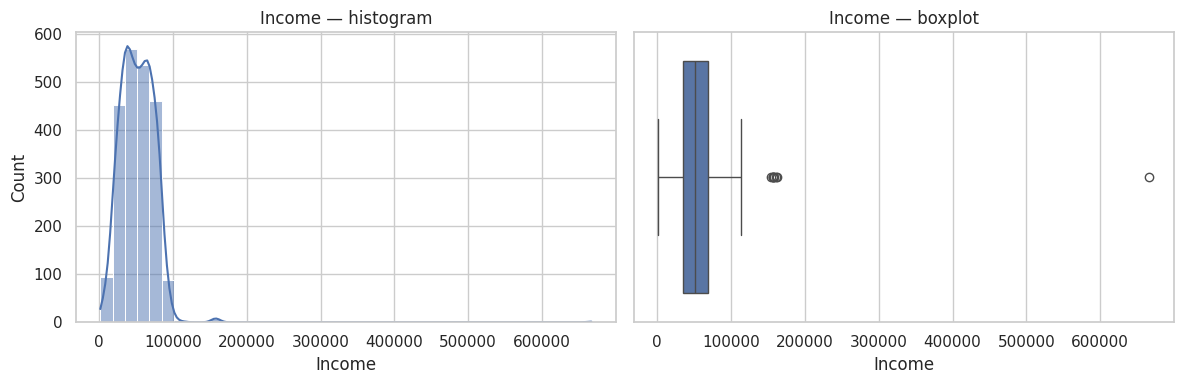

count      2213.000000
mean      52236.581563
std       25178.603047
min        1730.000000
25%       35246.000000
50%       51373.000000
75%       68487.000000
max      666666.000000
Name: Income, dtype: float64
IQR outlier bounds (1.5x rule): [-14615.50, 118348.50]
outliers: 8 rows (0.36% of non-missing data)
  below lower bound: 0, above upper bound: 8


In [13]:
# Income still has NaNs here (24 missing, not dropped in this notebook) — describe()/quantile skip NaN automatically, safe.
plot_numeric_distribution(df, "Income")

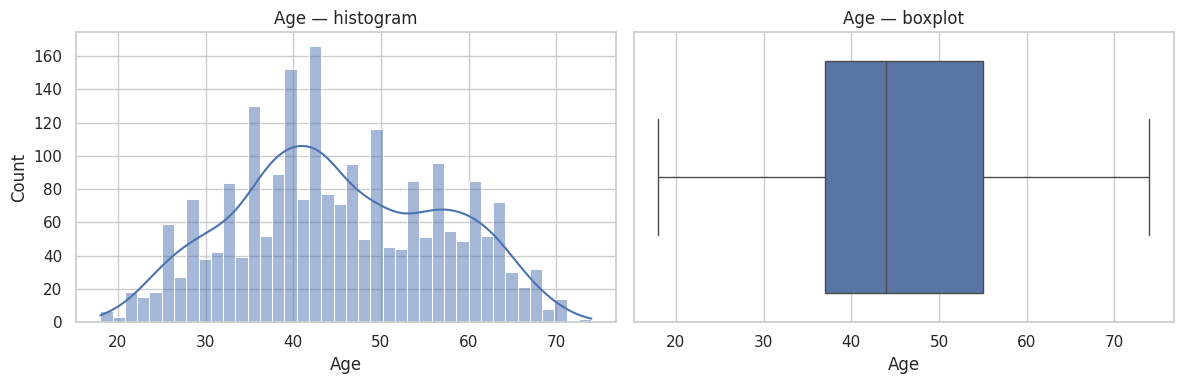

count    2237.000000
mean       45.098346
std        11.701917
min        18.000000
25%        37.000000
50%        44.000000
75%        55.000000
max        74.000000
Name: Age, dtype: float64
IQR outlier bounds (1.5x rule): [10.00, 82.00]
outliers: 0 rows (0.00% of non-missing data)


In [14]:
plot_numeric_distribution(df, "Age")

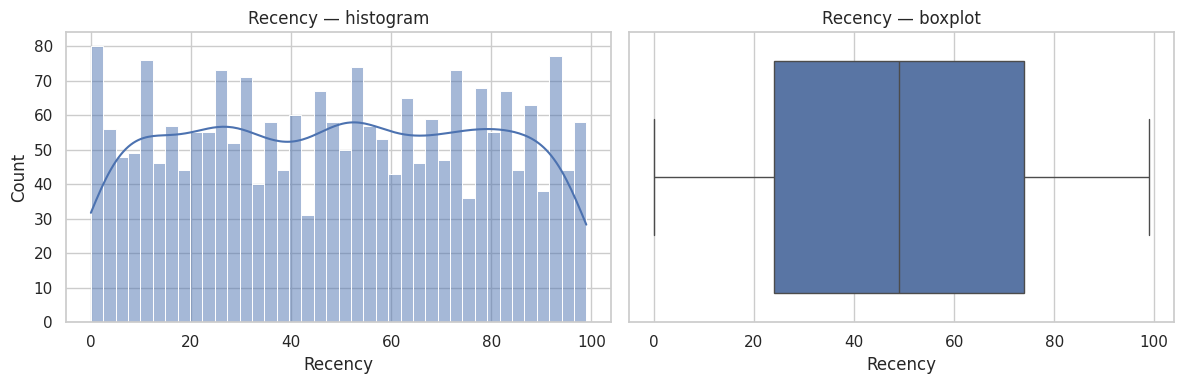

count    2237.000000
mean       49.104604
std        28.956073
min         0.000000
25%        24.000000
50%        49.000000
75%        74.000000
max        99.000000
Name: Recency, dtype: float64
IQR outlier bounds (1.5x rule): [-51.00, 149.00]
outliers: 0 rows (0.00% of non-missing data)


In [15]:
plot_numeric_distribution(df, "Recency")

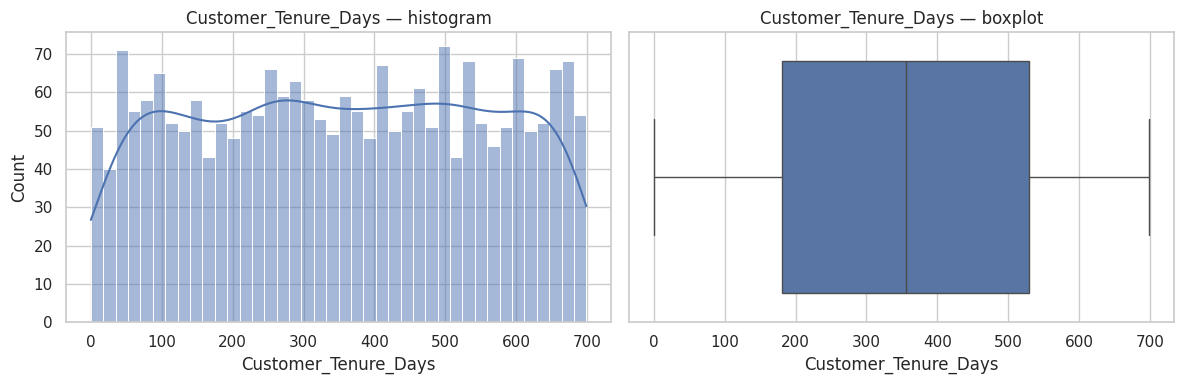

count    2237.000000
mean      353.790344
std       202.137961
min         0.000000
25%       181.000000
50%       356.000000
75%       529.000000
max       699.000000
Name: Customer_Tenure_Days, dtype: float64
IQR outlier bounds (1.5x rule): [-341.00, 1051.00]
outliers: 0 rows (0.00% of non-missing data)


In [16]:
plot_numeric_distribution(df, "Customer_Tenure_Days")

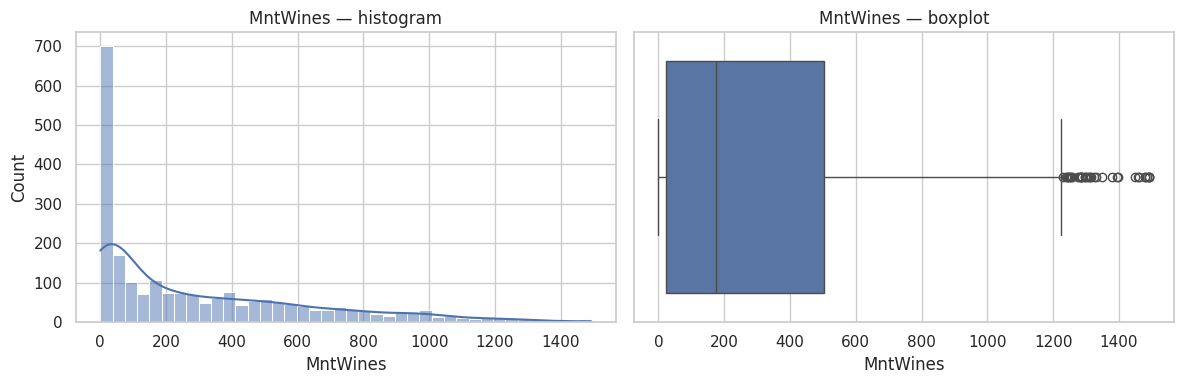

count    2237.000000
mean      303.995530
std       336.574382
min         0.000000
25%        24.000000
50%       174.000000
75%       504.000000
max      1493.000000
Name: MntWines, dtype: float64
IQR outlier bounds (1.5x rule): [-696.00, 1224.00]
outliers: 35 rows (1.56% of non-missing data)
  below lower bound: 0, above upper bound: 35


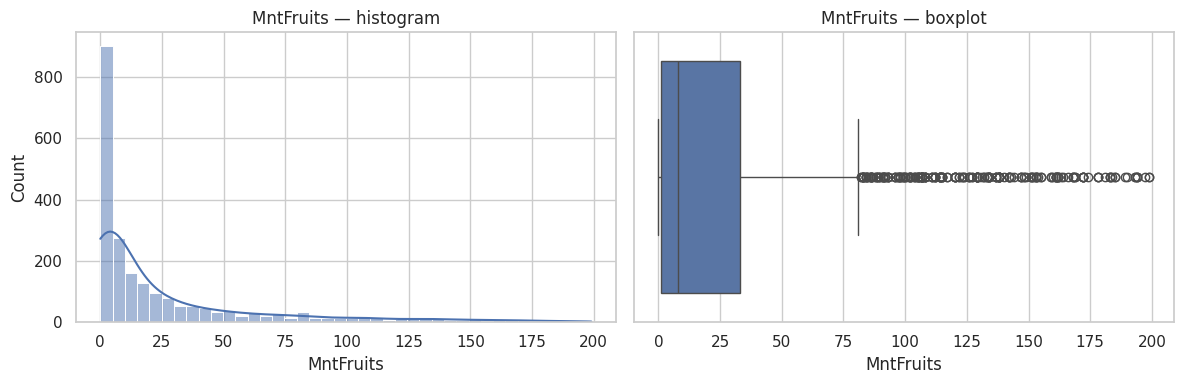

count    2237.000000
mean       26.270451
std        39.715972
min         0.000000
25%         1.000000
50%         8.000000
75%        33.000000
max       199.000000
Name: MntFruits, dtype: float64
IQR outlier bounds (1.5x rule): [-47.00, 81.00]
outliers: 226 rows (10.10% of non-missing data)
  below lower bound: 0, above upper bound: 226


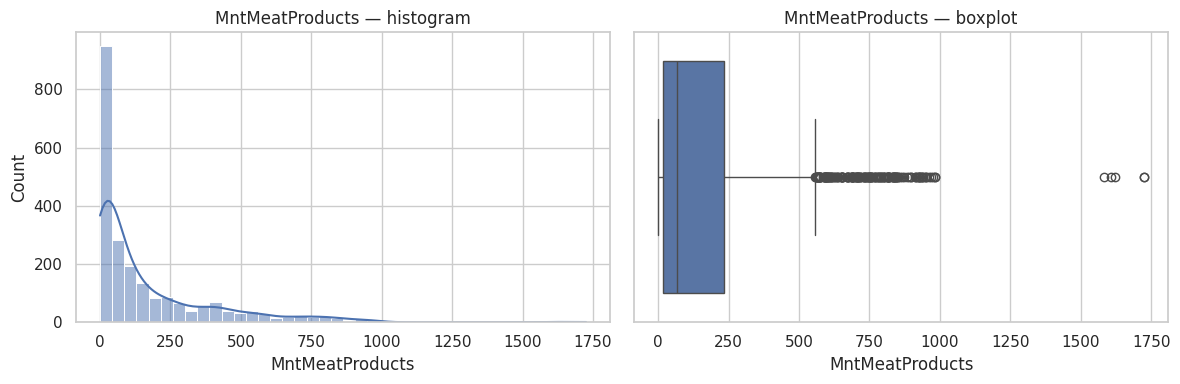

count    2237.000000
mean      166.916853
std       225.661158
min         0.000000
25%        16.000000
50%        67.000000
75%       232.000000
max      1725.000000
Name: MntMeatProducts, dtype: float64
IQR outlier bounds (1.5x rule): [-308.00, 556.00]
outliers: 174 rows (7.78% of non-missing data)
  below lower bound: 0, above upper bound: 174


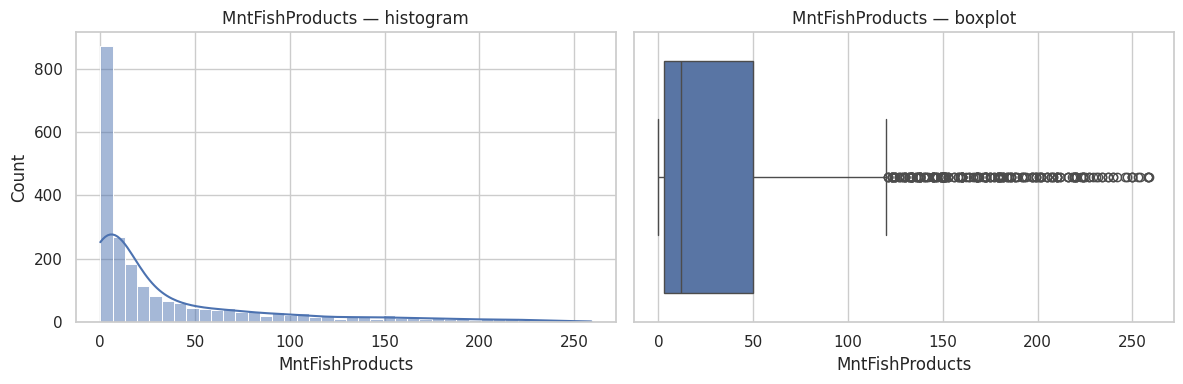

count    2237.000000
mean       37.523022
std        54.639909
min         0.000000
25%         3.000000
50%        12.000000
75%        50.000000
max       259.000000
Name: MntFishProducts, dtype: float64
IQR outlier bounds (1.5x rule): [-67.50, 120.50]
outliers: 223 rows (9.97% of non-missing data)
  below lower bound: 0, above upper bound: 223


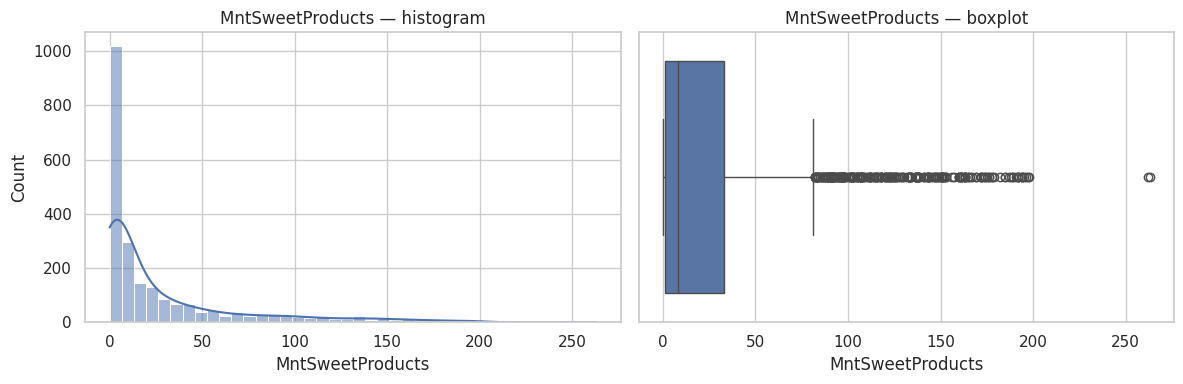

count    2237.000000
mean       27.068842
std        41.293949
min         0.000000
25%         1.000000
50%         8.000000
75%        33.000000
max       263.000000
Name: MntSweetProducts, dtype: float64
IQR outlier bounds (1.5x rule): [-47.00, 81.00]
outliers: 248 rows (11.09% of non-missing data)
  below lower bound: 0, above upper bound: 248


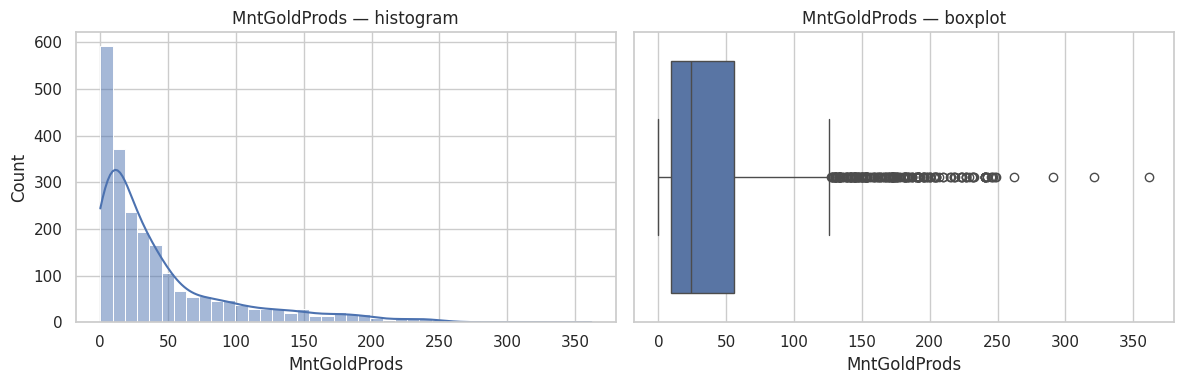

count    2237.000000
mean       43.968708
std        52.054318
min         0.000000
25%         9.000000
50%        24.000000
75%        56.000000
max       362.000000
Name: MntGoldProds, dtype: float64
IQR outlier bounds (1.5x rule): [-61.50, 126.50]
outliers: 206 rows (9.21% of non-missing data)
  below lower bound: 0, above upper bound: 206


In [17]:
# Product spend columns (Products group)
for col in ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']:
    plot_numeric_distribution(df, col)

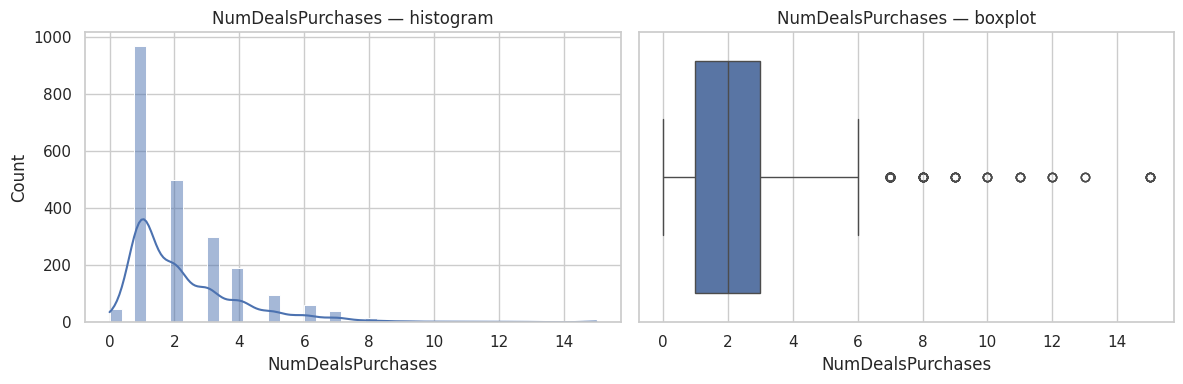

count    2237.000000
mean        2.326777
std         1.932923
min         0.000000
25%         1.000000
50%         2.000000
75%         3.000000
max        15.000000
Name: NumDealsPurchases, dtype: float64
IQR outlier bounds (1.5x rule): [-2.00, 6.00]
outliers: 86 rows (3.84% of non-missing data)
  below lower bound: 0, above upper bound: 86


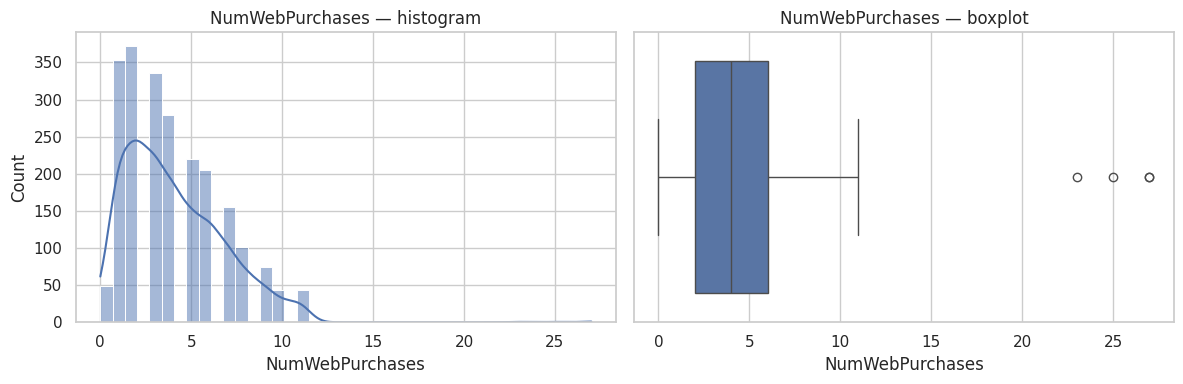

count    2237.000000
mean        4.087170
std         2.779461
min         0.000000
25%         2.000000
50%         4.000000
75%         6.000000
max        27.000000
Name: NumWebPurchases, dtype: float64
IQR outlier bounds (1.5x rule): [-4.00, 12.00]
outliers: 4 rows (0.18% of non-missing data)
  below lower bound: 0, above upper bound: 4


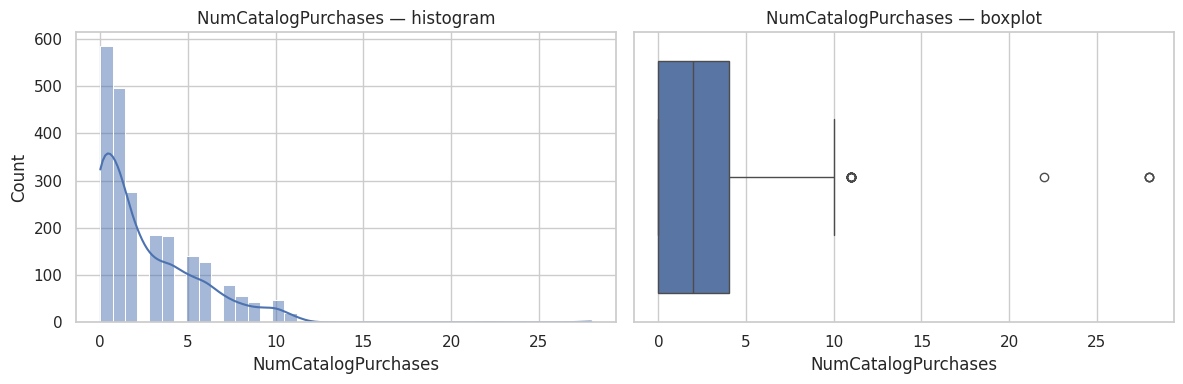

count    2237.000000
mean        2.662494
std         2.923456
min         0.000000
25%         0.000000
50%         2.000000
75%         4.000000
max        28.000000
Name: NumCatalogPurchases, dtype: float64
IQR outlier bounds (1.5x rule): [-6.00, 10.00]
outliers: 23 rows (1.03% of non-missing data)
  below lower bound: 0, above upper bound: 23


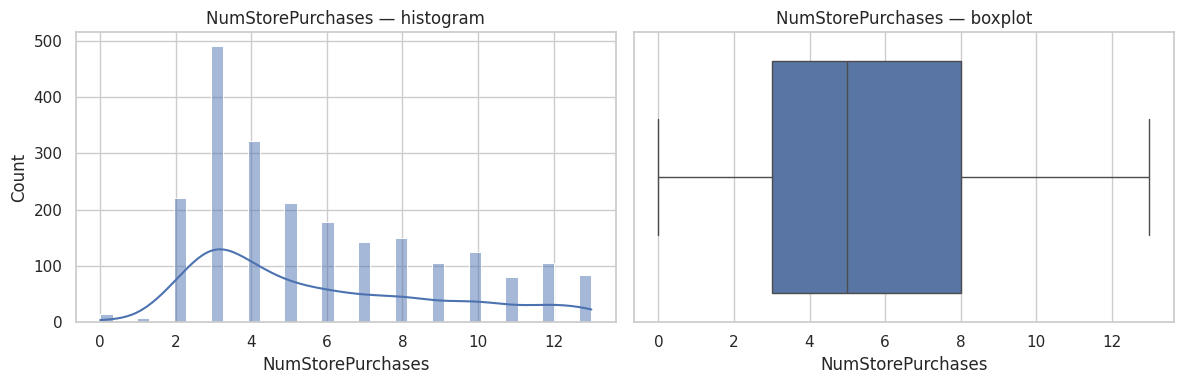

count    2237.000000
mean        5.794367
std         3.250940
min         0.000000
25%         3.000000
50%         5.000000
75%         8.000000
max        13.000000
Name: NumStorePurchases, dtype: float64
IQR outlier bounds (1.5x rule): [-4.50, 15.50]
outliers: 0 rows (0.00% of non-missing data)


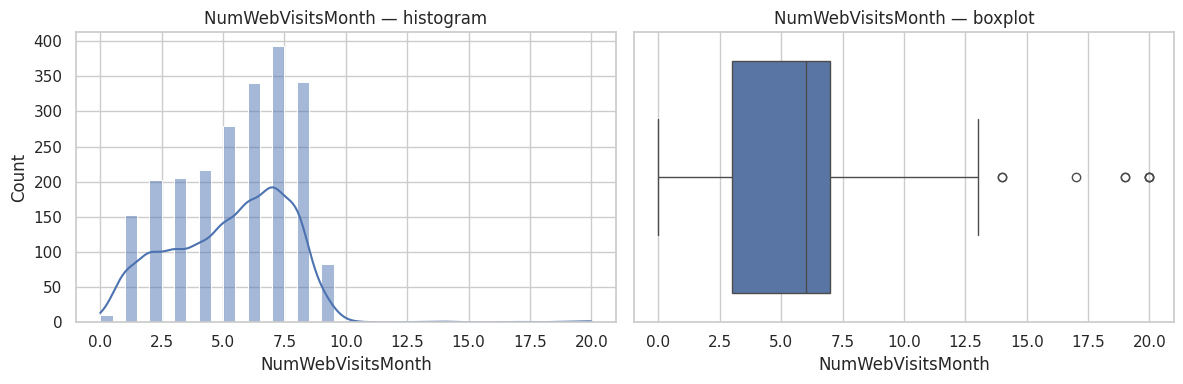

count    2237.000000
mean        5.319177
std         2.426386
min         0.000000
25%         3.000000
50%         6.000000
75%         7.000000
max        20.000000
Name: NumWebVisitsMonth, dtype: float64
IQR outlier bounds (1.5x rule): [-3.00, 13.00]
outliers: 8 rows (0.36% of non-missing data)
  below lower bound: 0, above upper bound: 8


In [18]:
# Purchase-channel + engagement columns (Place group)
for col in ['NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth']:
    plot_numeric_distribution(df, col)

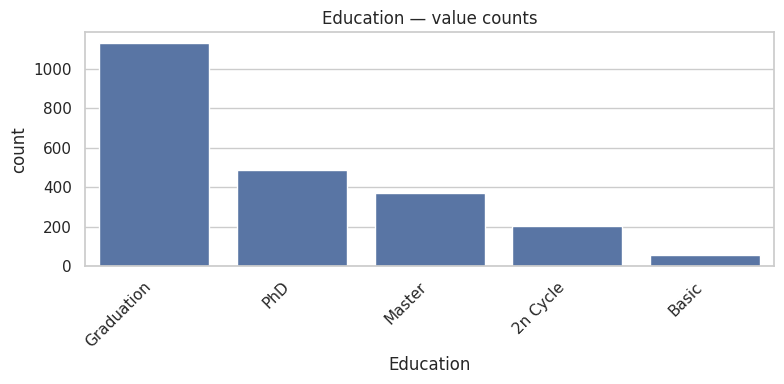

Education
Graduation    0.504
PhD           0.217
Master        0.165
2n Cycle      0.090
Basic         0.024
Name: proportion, dtype: float64


In [19]:
plot_categorical_distribution(df, "Education")

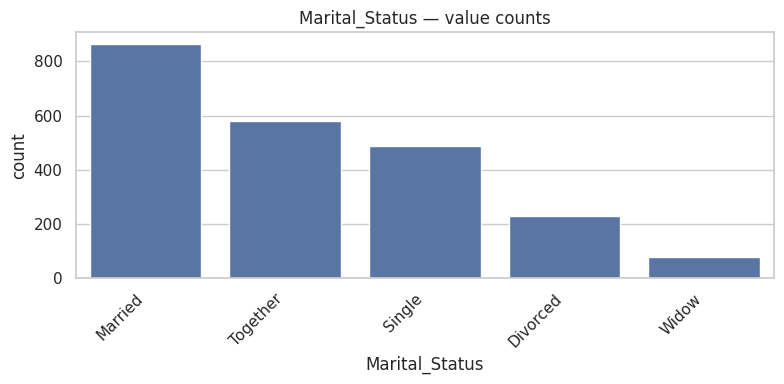

Marital_Status
Married     0.386
Together    0.259
Single      0.217
Divorced    0.103
Widow       0.034
Name: proportion, dtype: float64


In [20]:
plot_categorical_distribution(df, "Marital_Status")

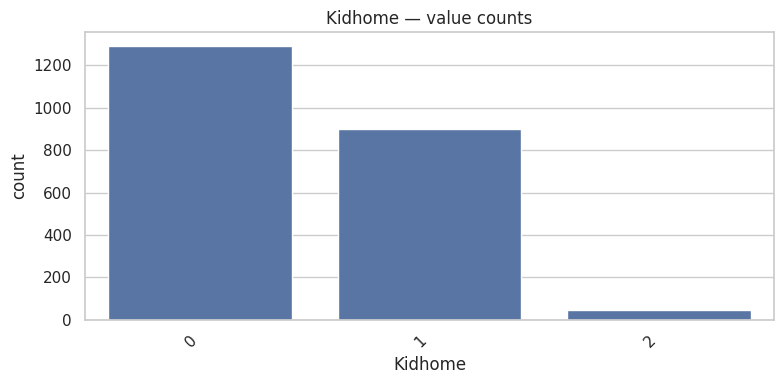

Kidhome
0    0.577
1    0.401
2    0.021
Name: proportion, dtype: float64


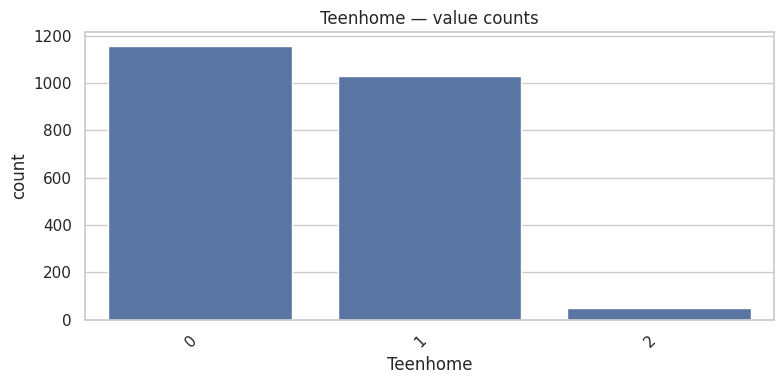

Teenhome
0    0.517
1    0.460
2    0.023
Name: proportion, dtype: float64


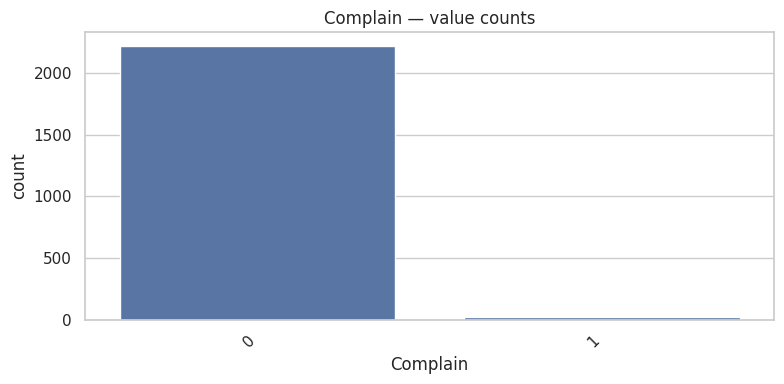

Complain
0    0.991
1    0.009
Name: proportion, dtype: float64


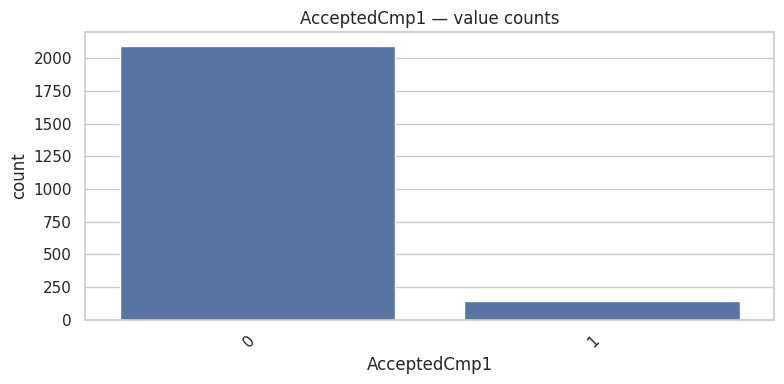

AcceptedCmp1
0    0.936
1    0.064
Name: proportion, dtype: float64


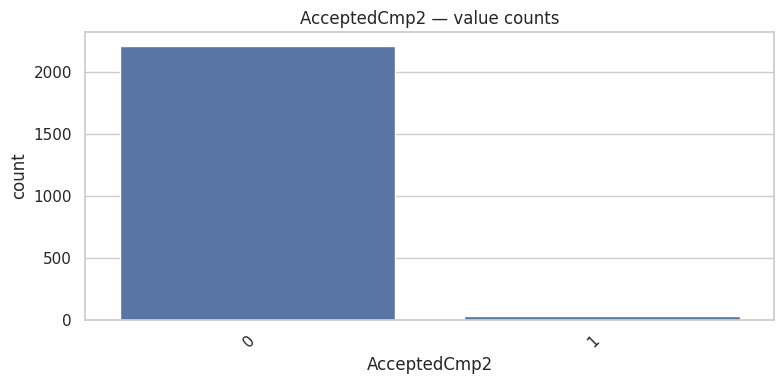

AcceptedCmp2
0    0.987
1    0.013
Name: proportion, dtype: float64


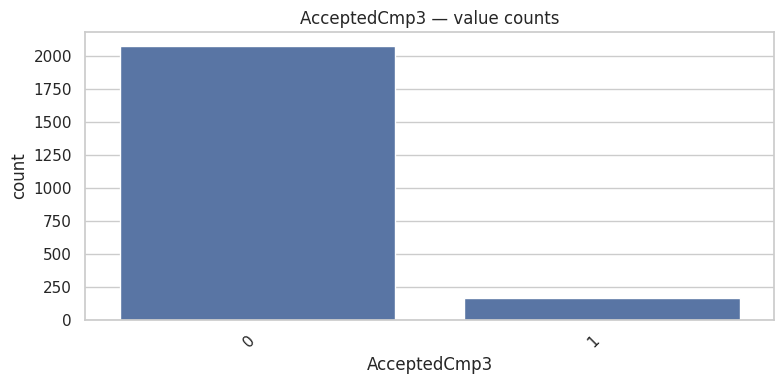

AcceptedCmp3
0    0.927
1    0.073
Name: proportion, dtype: float64


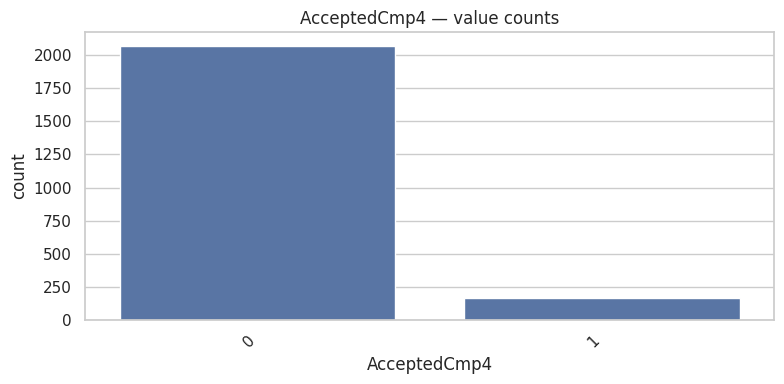

AcceptedCmp4
0    0.925
1    0.075
Name: proportion, dtype: float64


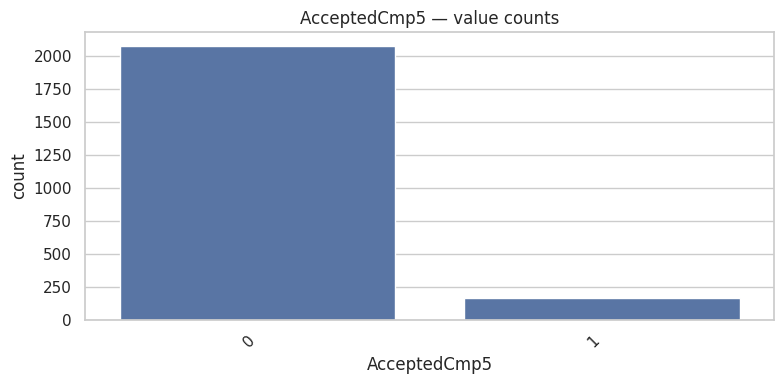

AcceptedCmp5
0    0.928
1    0.072
Name: proportion, dtype: float64


In [21]:
# Binary flags: household composition, complaints, prior-campaign acceptance (Promotion group)
for col in ['Kidhome', 'Teenhome', 'Complain', 'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']:
    plot_categorical_distribution(df, col)

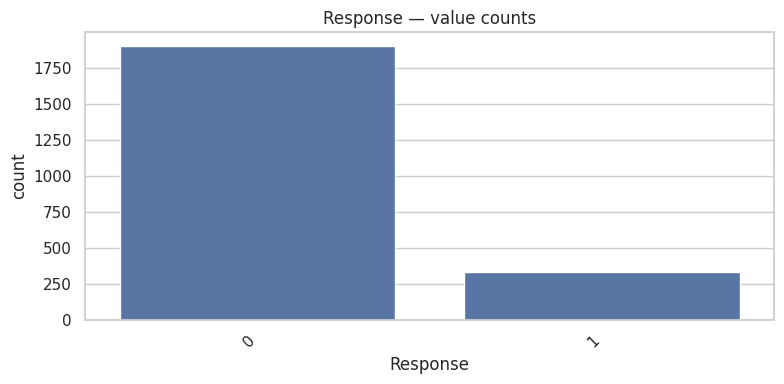

Response
0    0.851
1    0.149
Name: proportion, dtype: float64
class balance — Response (accepted last campaign): 14.9%


In [22]:
plot_categorical_distribution(df, "Response")
resp_rate = df['Response'].mean()
print(f"class balance — Response (accepted last campaign): {resp_rate:.1%}")

## Relevance vs. Classification Target (Response) — Correlation First

In [23]:
numeric_cols = ['Income', 'Age', 'Recency', 'Kidhome', 'Teenhome', 'Customer_Tenure_Days', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'Complain', 'AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']
categorical_cols = ['Education', 'Marital_Status']
# AcceptedCmp1-5 (prior-campaign acceptance flags) are included here but are genuine leakage-adjacent
# features for Response — flagged explicitly below, same treatment as duration (banking_dataset) and
# Reviews_num (google_play_data): shown in the ranking, not silently dropped.

def cramers_v(a, b):
    mask = a.notna() & b.notna()
    table = pd.crosstab(a[mask], b[mask])
    chi2 = chi2_contingency(table)[0]
    n = table.to_numpy().sum()
    r, k = table.shape
    return np.sqrt((chi2 / n) / (min(r, k) - 1))

def point_biserial(a, target):
    mask = a.notna()
    corr, _ = pointbiserialr(target[mask], a[mask])
    return abs(corr)

relevance = {}
for col in numeric_cols:
    relevance[col] = point_biserial(df[col], df["Response"])
for col in categorical_cols:
    relevance[col] = cramers_v(df[col], df["Response"])

relevance = pd.Series(relevance).sort_values(ascending=False)
relevance_df = relevance.rename("relevance_score").to_frame()
relevance_df["type"] = ["numeric" if c in numeric_cols else "categorical" for c in relevance_df.index]
relevance_df

,relevance_score,type
AcceptedCmp5,0.328182,numeric
AcceptedCmp1,0.293882,numeric
AcceptedCmp3,0.254144,numeric
MntWines,0.247392,numeric
MntMeatProducts,0.236640,numeric
NumCatalogPurchases,0.220894,numeric
Recency,0.198568,numeric
Customer_Tenure_Days,0.194187,numeric
AcceptedCmp4,0.176890,numeric
AcceptedCmp2,0.169249,numeric


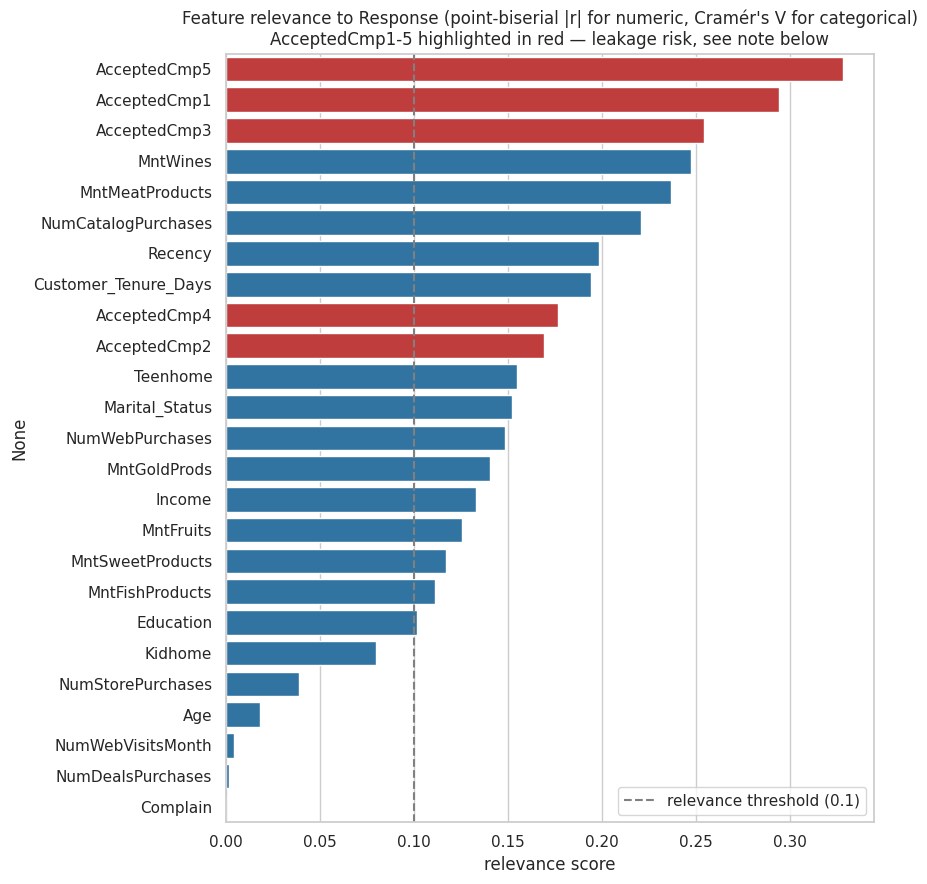

features clearing relevance threshold (0.1): ['AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp3', 'MntWines', 'MntMeatProducts', 'NumCatalogPurchases', 'Recency', 'Customer_Tenure_Days', 'AcceptedCmp4', 'AcceptedCmp2', 'Teenhome', 'Marital_Status', 'NumWebPurchases', 'MntGoldProds', 'Income', 'MntFruits', 'MntSweetProducts', 'MntFishProducts', 'Education']


In [24]:
accepted_cols = ['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5']
plt.figure(figsize=(9, 9))
colors = ["#d62728" if c in accepted_cols else "#1f77b4" for c in relevance.index]
sns.barplot(x=relevance.values, y=relevance.index, hue=relevance.index, palette=colors, legend=False)
plt.axvline(0.1, color="gray", linestyle="--", label="relevance threshold (0.1)")
plt.title("Feature relevance to Response (point-biserial |r| for numeric, Cramér's V for categorical)\nAcceptedCmp1-5 highlighted in red — leakage risk, see note below")
plt.xlabel("relevance score")
plt.legend()
plt.tight_layout()
plt.show()

RELEVANCE_THRESHOLD = 0.1
top_features = relevance[relevance >= RELEVANCE_THRESHOLD].index.tolist()
print(f"features clearing relevance threshold ({RELEVANCE_THRESHOLD}): {top_features}")

In [25]:
print("leakage note: AcceptedCmp1-5 flag acceptance of the five *earlier* campaigns. A customer who "
      "accepted a prior campaign is mechanically more likely to be a responsive, engaged customer — "
      "the same kind of customer likely to accept the *current* campaign (Response) too. This is not "
      "circular by construction (unlike Installs_num -> hit in google_play_data), but it is a strong "
      "behavioral proxy that a real prospective-targeting model would not have at decision time for a "
      "brand-new prospect.")

any_prior_accept = df[accepted_cols].sum(axis=1) > 0
print("\nResponse rate given any prior campaign acceptance vs. none:")
df.groupby(any_prior_accept)["Response"].agg(["mean", "count"])

leakage note: AcceptedCmp1-5 flag acceptance of the five *earlier* campaigns. A customer who accepted a prior campaign is mechanically more likely to be a responsive, engaged customer — the same kind of customer likely to accept the *current* campaign (Response) too. This is not circular by construction (unlike Installs_num -> hit in google_play_data), but it is a strong behavioral proxy that a real prospective-targeting model would not have at decision time for a brand-new prospect.

Response rate given any prior campaign acceptance vs. none:


,mean,count
False,0.082254,1775
True,0.406926,462


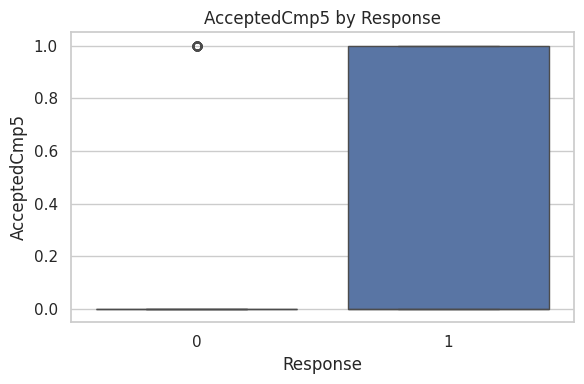

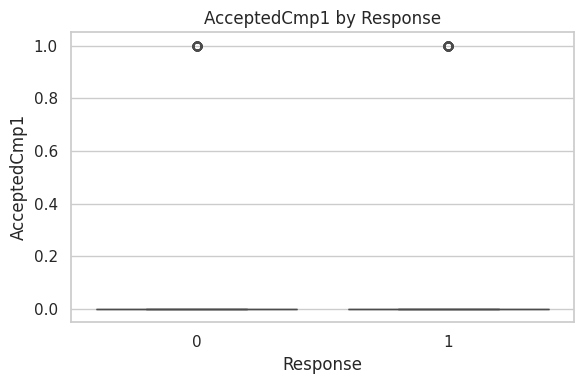

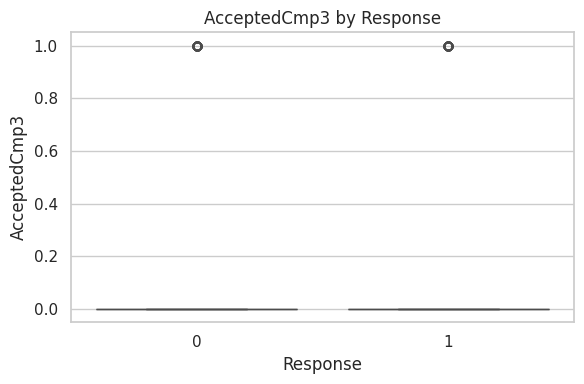

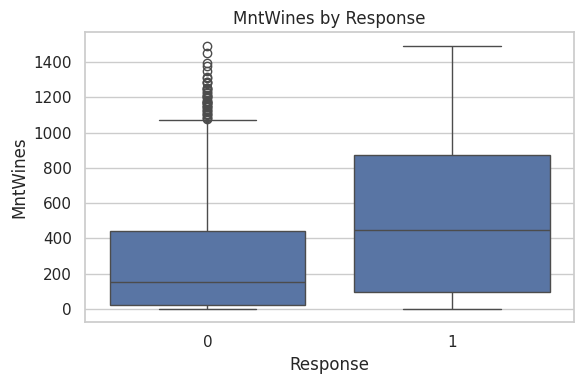

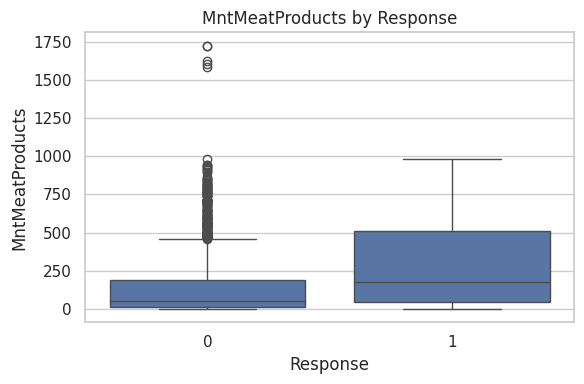

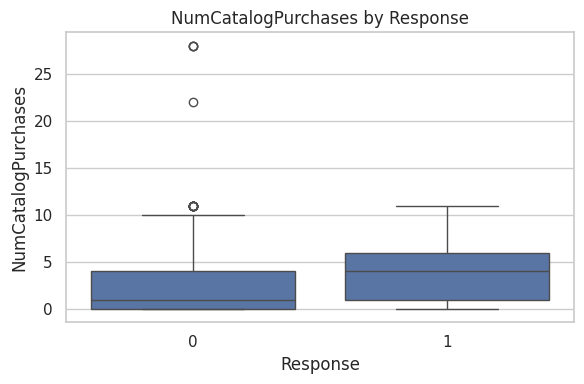

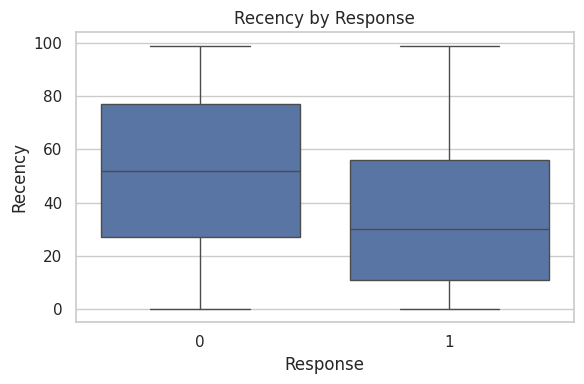

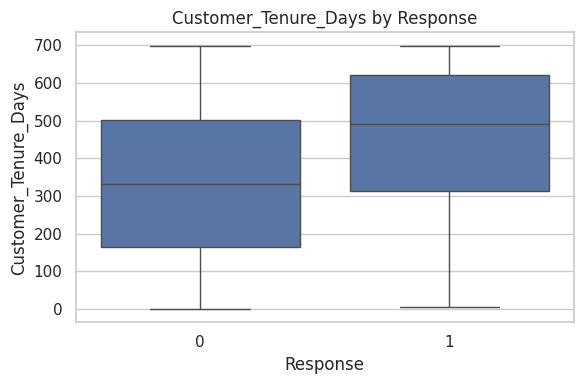

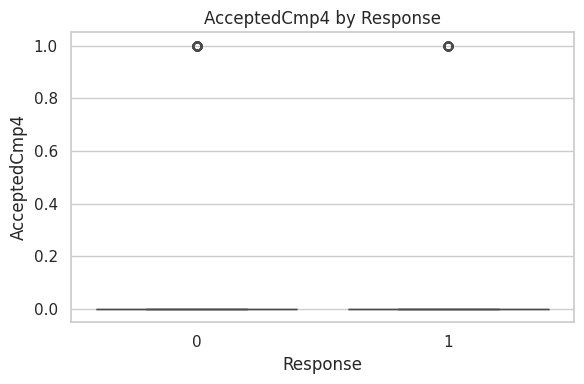

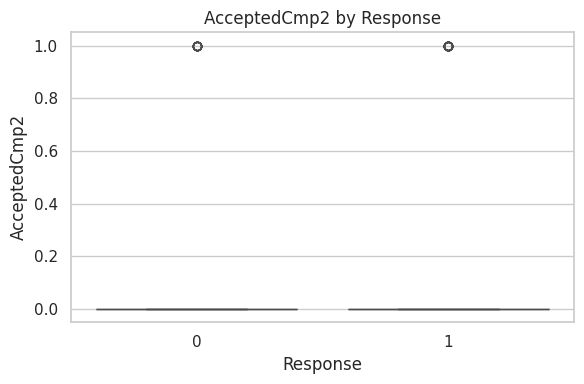

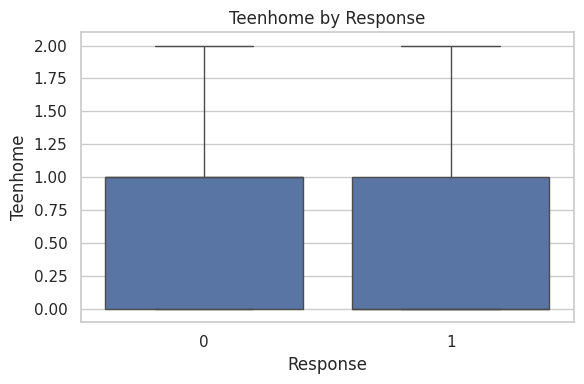

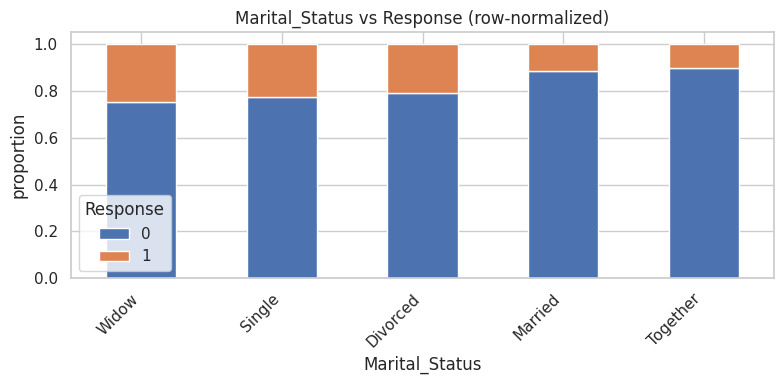

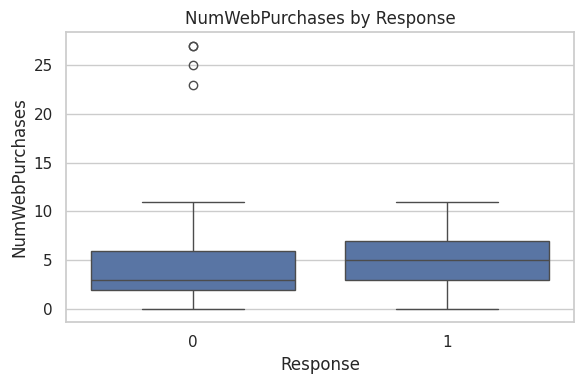

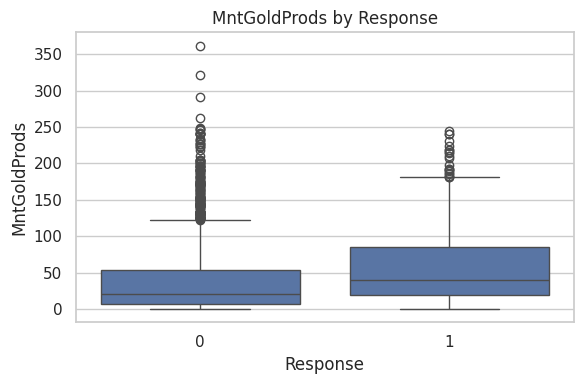

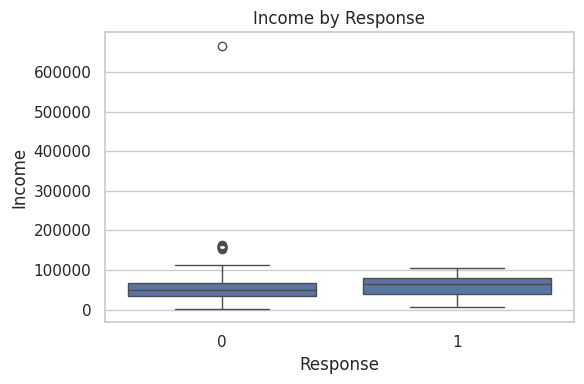

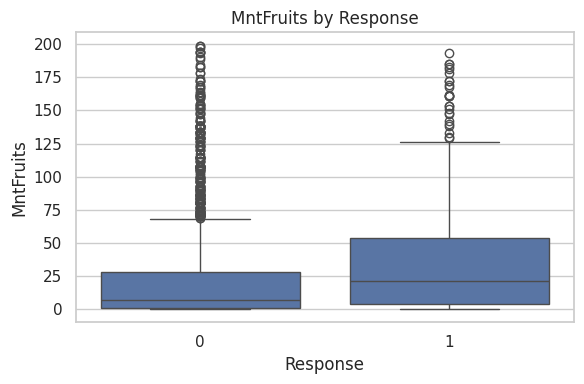

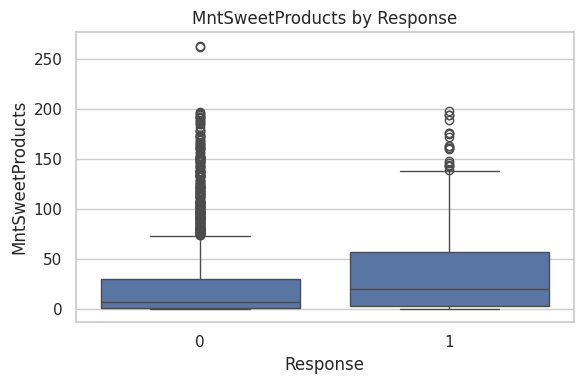

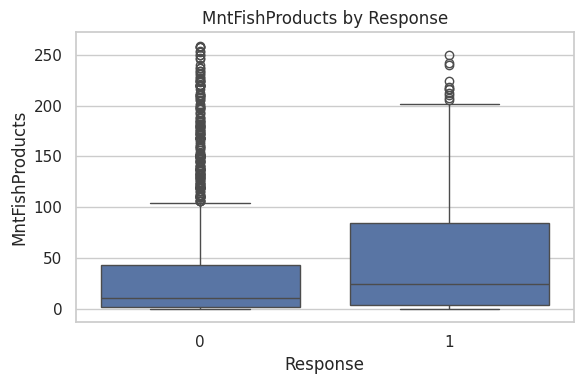

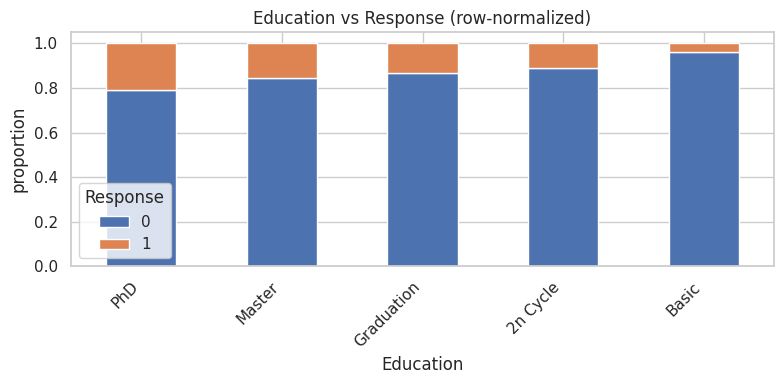

In [26]:
def plot_numeric_vs_target(df, col, target="Response"):
    plt.figure(figsize=(6, 4))
    sns.boxplot(x=df[target], y=df[col])
    plt.title(f"{col} by {target}")
    plt.tight_layout()
    plt.show()

def plot_categorical_vs_target(df, col, target="Response"):
    ct = pd.crosstab(df[col], df[target], normalize="index")
    order = ct.sort_values(by=ct.columns[-1], ascending=False).index
    ct.loc[order].plot(kind="bar", stacked=True, figsize=(8, 4))
    plt.title(f"{col} vs {target} (row-normalized)")
    plt.ylabel("proportion")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    plt.show()

for col in top_features:
    if col in numeric_cols:
        plot_numeric_vs_target(df, col)
    else:
        plot_categorical_vs_target(df, col)

## Multicollinearity (numeric feature-to-feature)

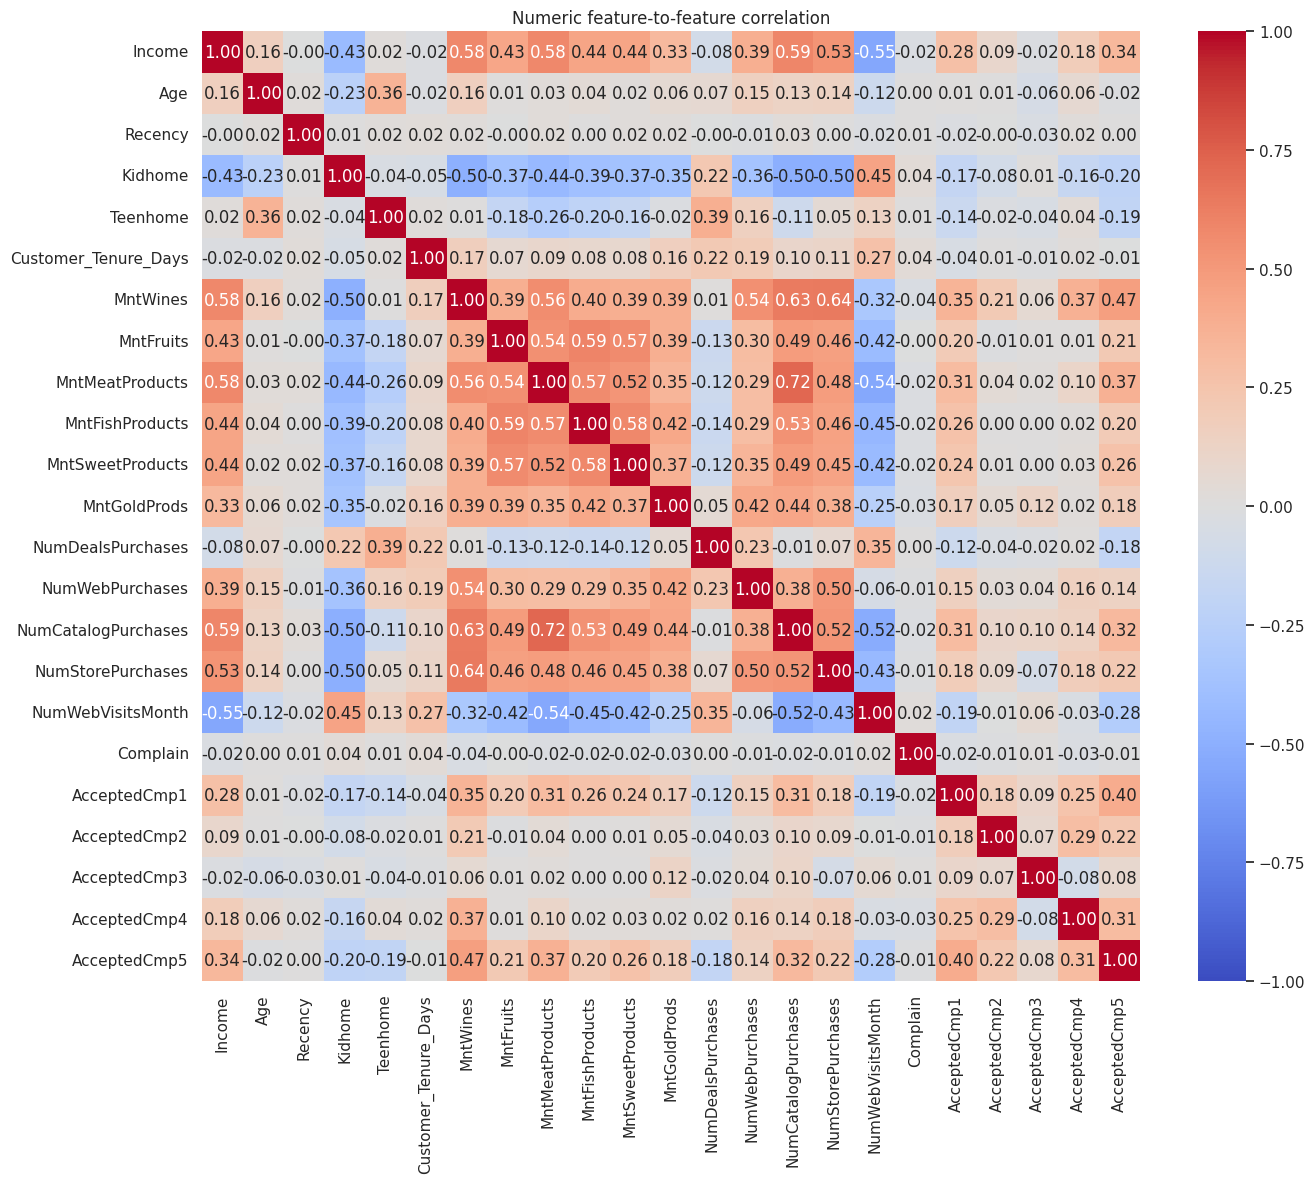

In [27]:
corr_matrix = df[numeric_cols].corr()
plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Numeric feature-to-feature correlation")
plt.tight_layout()
plt.show()

## Categorical Redundancy (Education vs. Marital_Status)

In [28]:
# Only two categorical candidates here (far fewer than google_play_data's four or banking_dataset's
# nine) — a single pairwise score is enough, no heatmap needed.
edu_marital_v = cramers_v(df['Education'], df['Marital_Status'])
print(f"Cramér's V(Education, Marital_Status) = {edu_marital_v:.3f}")

Cramér's V(Education, Marital_Status) = 0.043


## Model-Based Feature Importance (RF)

In [29]:
def build_feature_matrix(df, num_cols, cat_cols):
    X_num = df[num_cols].copy()
    for c in num_cols:
        X_num[c] = X_num[c].fillna(X_num[c].median())
    frames = [X_num]
    col_to_parent = {c: c for c in num_cols}
    for col in cat_cols:
        dummies = pd.get_dummies(df[col].fillna("__missing__"), prefix=col)
        frames.append(dummies)
        col_to_parent.update({d: col for d in dummies.columns})
    return pd.concat(frames, axis=1), col_to_parent

# Median-fill for Income (the only numeric column with NaNs at this stage) is a modeling-only
# convenience for RF/MI, which need a complete matrix — not applied anywhere else in the notebook.
X_clf, col_to_parent_clf = build_feature_matrix(df, numeric_cols, categorical_cols)
rf_clf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
rf_clf.fit(X_clf, df["Response"])

importances_clf = pd.Series(rf_clf.feature_importances_, index=X_clf.columns)
importances_clf_agg = importances_clf.groupby(col_to_parent_clf).sum().sort_values(ascending=False)
importances_clf_agg

Recency                 0.087798
Customer_Tenure_Days    0.081529
Income                  0.072085
MntWines                0.070497
MntMeatProducts         0.069420
MntGoldProds            0.050453
Marital_Status          0.045575
Age                     0.045497
AcceptedCmp3            0.042146
MntSweetProducts        0.041571
MntFishProducts         0.040455
AcceptedCmp5            0.040392
MntFruits               0.039160
NumStorePurchases       0.038715
NumCatalogPurchases     0.037745
NumWebVisitsMonth       0.036199
AcceptedCmp1            0.033061
Education               0.030806
NumWebPurchases         0.030402
NumDealsPurchases       0.028258
Teenhome                0.012116
AcceptedCmp4            0.010022
AcceptedCmp2            0.008041
Kidhome                 0.007486
Complain                0.000575
dtype: float64

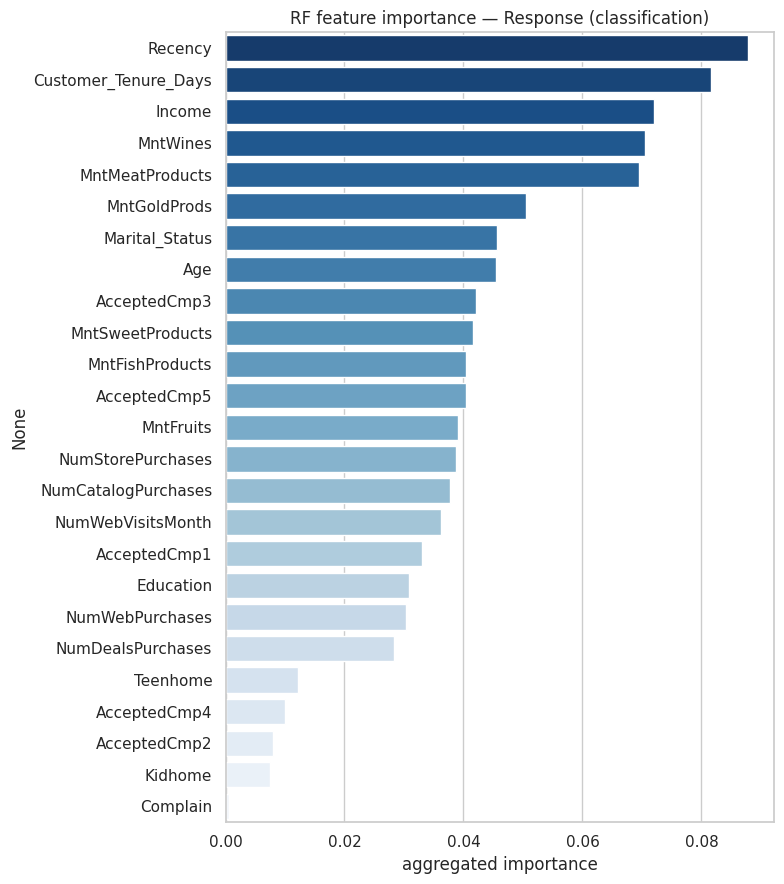

In [30]:
plt.figure(figsize=(8, 9))
sns.barplot(x=importances_clf_agg.values, y=importances_clf_agg.index, hue=importances_clf_agg.index,
            palette="Blues_r", legend=False)
plt.title("RF feature importance — Response (classification)")
plt.xlabel("aggregated importance")
plt.tight_layout()
plt.show()

## Relevance Cross-Check — Mutual Information

In [31]:
from sklearn.feature_selection import mutual_info_classif

mi_numeric = pd.Series(
    mutual_info_classif(X_clf[numeric_cols], df["Response"], discrete_features=False, random_state=42),
    index=numeric_cols,
)

cat_codes = df[categorical_cols].fillna("__missing__").apply(lambda s: pd.factorize(s)[0])
mi_categorical = pd.Series(
    mutual_info_classif(cat_codes, df["Response"], discrete_features=True, random_state=42),
    index=categorical_cols,
)

mi_relevance = pd.concat([mi_numeric, mi_categorical]).sort_values(ascending=False)
mi_relevance_df = mi_relevance.rename("mutual_info").to_frame()
mi_relevance_df["type"] = ["numeric" if c in numeric_cols else "categorical" for c in mi_relevance_df.index]
mi_relevance_df

,mutual_info,type
MntMeatProducts,0.042532,numeric
AcceptedCmp5,0.041951,numeric
MntWines,0.040311,numeric
Income,0.037114,numeric
MntGoldProds,0.034321,numeric
NumCatalogPurchases,0.033766,numeric
Customer_Tenure_Days,0.031621,numeric
NumWebPurchases,0.031606,numeric
AcceptedCmp3,0.026625,numeric
Recency,0.024835,numeric


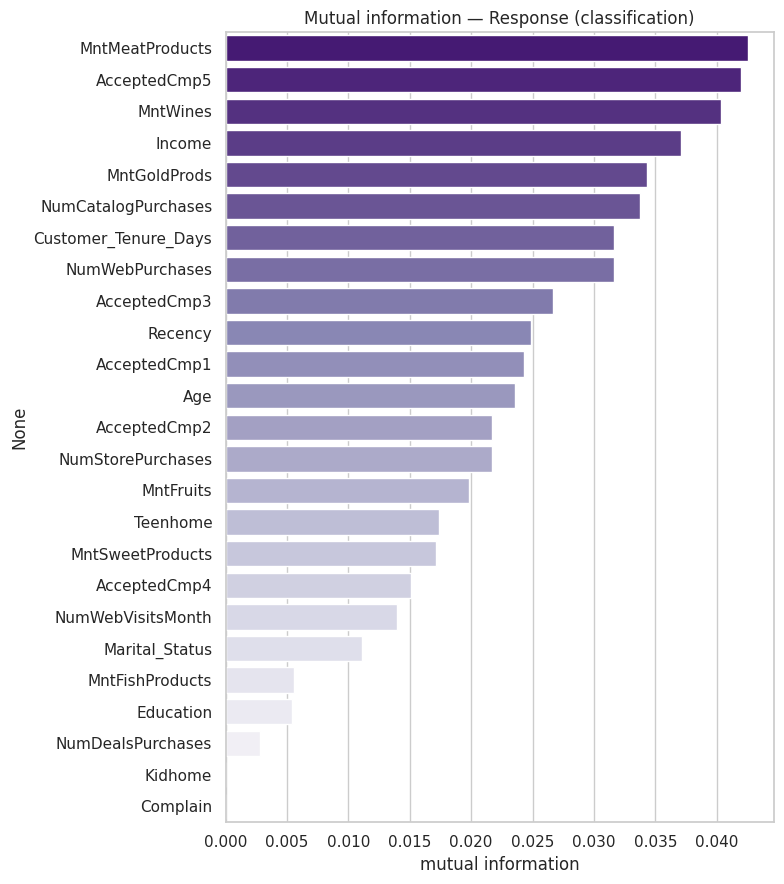

In [32]:
plt.figure(figsize=(8, 9))
sns.barplot(x=mi_relevance.values, y=mi_relevance.index, hue=mi_relevance.index,
            palette="Purples_r", legend=False)
plt.title("Mutual information — Response (classification)")
plt.xlabel("mutual information")
plt.tight_layout()
plt.show()